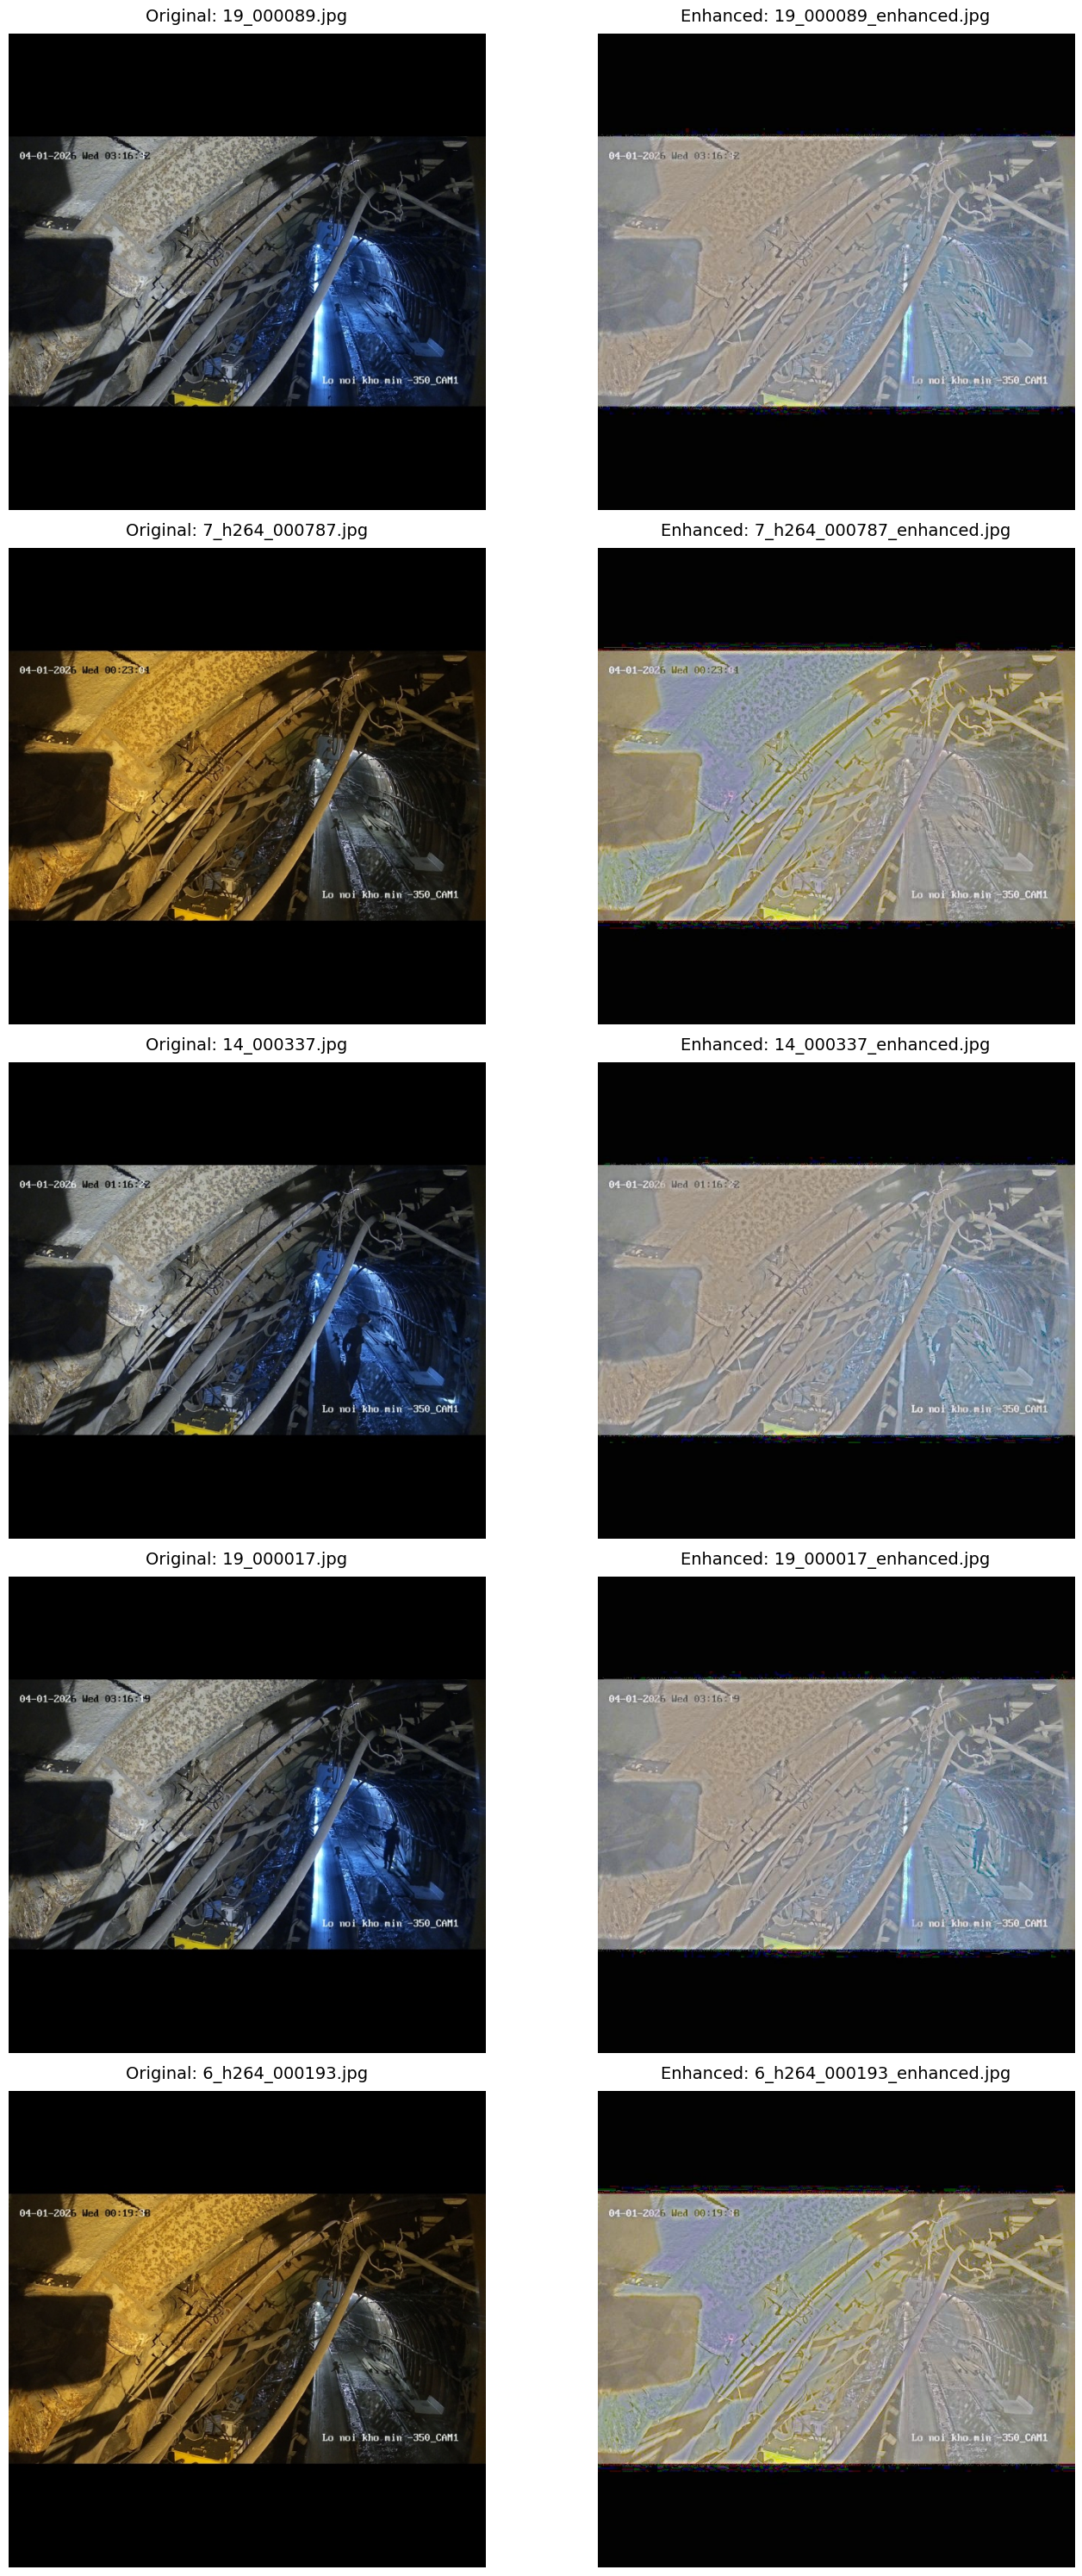

In [3]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

def visualize_random_enhanced_images(test_dir='dataset/test', results_dir='results', num_images=5):
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.JPG', '.JPEG', '.PNG')
    all_images = [f for f in os.listdir(test_dir) if f.endswith(valid_extensions)]
    
    if len(all_images) < num_images:
        print(f"Warning: Only found {len(all_images)} images. Displaying all.")
        num_images = len(all_images)
        
    if num_images == 0:
        print("No images found.")
        return

    random_images = random.sample(all_images, num_images)
    
    # --- CHANGED: Increased figsize (width=16, height=6 per row) and added dpi=100 for higher quality ---
    fig, axes = plt.subplots(num_images, 2, figsize=(16, 6 * num_images), dpi=100)
    
    if num_images == 1:
        axes = [axes]

    for i, img_name in enumerate(random_images):
        name_without_ext, ext = os.path.splitext(img_name)
        enhanced_img_name = f"{name_without_ext}_enhanced{ext}"
        
        orig_path = os.path.join(test_dir, img_name)
        enhanced_path = os.path.join(results_dir, enhanced_img_name)
        
        # Original Image
        ax_orig = axes[i][0]
        if os.path.exists(orig_path):
            img_orig = Image.open(orig_path)
            ax_orig.imshow(img_orig)
            # --- CHANGED: Increased fontsize to match the larger image size ---
            ax_orig.set_title(f"Original: {img_name}", fontsize=14, pad=10)
        else:
            ax_orig.text(0.5, 0.5, 'Not Found', ha='center', va='center', fontsize=14)
        ax_orig.axis('off')
        
        # Enhanced Image
        ax_enh = axes[i][1]
        if os.path.exists(enhanced_path):
            img_enh = Image.open(enhanced_path)
            ax_enh.imshow(img_enh)
            # --- CHANGED: Increased fontsize to match the larger image size ---
            ax_enh.set_title(f"Enhanced: {enhanced_img_name}", fontsize=14, pad=10)
        else:
            ax_enh.text(0.5, 0.5, f'Missing:\n{enhanced_img_name}', ha='center', va='center', color='red', fontsize=14)
        ax_enh.axis('off')
        
    # --- CHANGED: Adjusted subplots spacing so titles and images do not overlap ---
    plt.subplots_adjust(hspace=0.3, wspace=0.1)
    plt.tight_layout()
    plt.show()


# Cách sử dụng hàm:
visualize_random_enhanced_images()


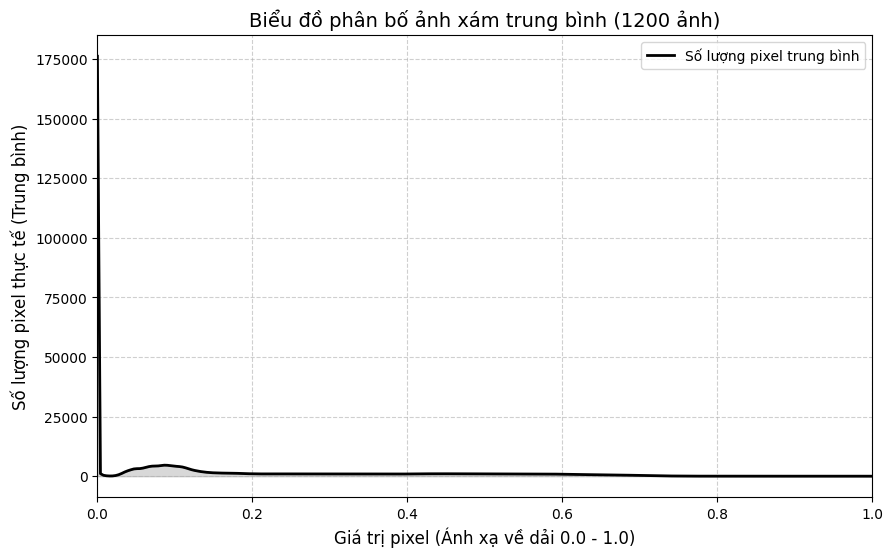

In [8]:
import cv2
import glob
import os
import matplotlib.pyplot as plt
import numpy as np


def plot_average_gray_histogram_no_norm(folder_path):
    # Định nghĩa các đuôi file ảnh phổ biến
    extensions = ("*.jpg", "*.jpeg", "*.png", "*.bmp")
    image_paths = []

    for ext in extensions:
        image_paths.extend(glob.glob(os.path.join(folder_path, ext)))

    if not image_paths:
        print("Không tìm thấy ảnh nào trong thư mục được chỉ định.")
        return

    # Mảng tích lũy cho histogram (256 mức xám)
    total_hist = np.zeros(256)
    valid_image_count = 0

    for img_path in image_paths:
        # Đọc ảnh trực tiếp ở dạng ảnh xám (Grayscale)
        img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img_gray is None:
            continue

        valid_image_count += 1

        # Tính toán số lượng pixel thực tế cho từng mức xám
        hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256]).flatten()


        # Cộng dồn trực tiếp số lượng pixel vào mảng tổng (không chuẩn hóa)
        total_hist += hist

    if valid_image_count == 0:
        print("Không thể đọc được ảnh nào hợp lệ.")
        return

    # Tính số lượng pixel trung bình trên mỗi ảnh
    avg_hist = total_hist / valid_image_count

    # Ánh xạ dải 256 mức xám sang phân vùng từ 0.0 đến 1.0 trên trục X
    x_axis = np.linspace(0, 1, 256)

    # Vẽ biểu đồ phân bố điểm ảnh xám trung bình
    plt.figure(figsize=(10, 6))
    plt.plot(
        x_axis,
        avg_hist,
        color="black",
        linewidth=2,
        label="Số lượng pixel trung bình",
    )

    # Đổ màu dưới đường cong để trực quan hơn
    plt.fill_between(x_axis, avg_hist, color="gray", alpha=0.3)

    plt.title(
        f"Biểu đồ phân bố ảnh xám trung bình ({valid_image_count} ảnh)",
        fontsize=14,
    )
    plt.xlabel("Giá trị pixel (Ánh xạ về dải 0.0 - 1.0)", fontsize=12)
    plt.ylabel("Số lượng pixel thực tế (Trung bình)", fontsize=12)
    plt.xlim(0, 1)  # Giới hạn trục X từ 0 đến 1
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()


# --- Cách sử dụng ---
FOLDER_PATH = "dataset/train"
plot_average_gray_histogram_no_norm(FOLDER_PATH)


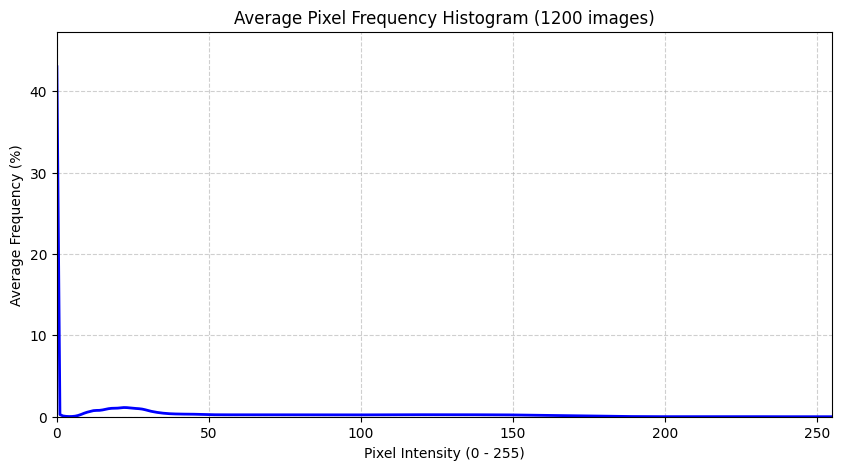

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def plot_average_frequency_histogram(folder_path):
    # Khởi tạo mảng tích lũy tần suất (256 mức xám)
    total_frequency = np.zeros((256, 1))
    valid_image_count = 0
    
    # Định dạng ảnh được hỗ trợ
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp')
    
    # Đọc từng tệp tin trong thư mục
    for file_name in os.listdir(folder_path):
        if file_name.lower().endswith(valid_extensions):
            file_path = os.path.join(folder_path, file_name)
            
            # Đọc ảnh trực tiếp ở dạng ảnh xám
            img_gray = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
            
            if img_gray is not None:
                # 1. Tính toán histogram số lượng pixel tuyệt đối
                hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256])
                
                # 2. Chuẩn hóa sang tần suất (tổng các cột bằng 1.0 hoặc 100%)
                # Chia cho tổng số pixel của chính ảnh đó (Width x Height)
                total_pixels = img_gray.shape[0] * img_gray.shape[1]
                img_frequency = hist / total_pixels
                
                # Tích lũy tần suất vào mảng chung
                total_frequency += img_frequency
                valid_image_count += 1
            else:
                print(f"Không thể đọc ảnh: {file_name}")
                
    if valid_image_count == 0:
        print("Không tìm thấy ảnh hợp lệ nào trong thư mục.")
        return

    # Tính toán tần suất trung bình của toàn bộ thư mục
    average_frequency = total_frequency / valid_image_count
    
    # Chuyển đổi sang đơn vị phần trăm (%) để hiển thị trực quan
    average_percentage = average_frequency * 100

    # Hiển thị biểu đồ tần suất pixel trung bình
    plt.figure(figsize=(10, 5))
    plt.title(f"Average Pixel Frequency Histogram ({valid_image_count} images)")
    plt.xlabel("Pixel Intensity (0 - 255)")
    plt.ylabel("Average Frequency (%)") # Trục Y hiển thị phần trăm
    
    # Vẽ biểu đồ dạng đường (Line plot) hoặc dạng cột (Bar plot)
    plt.plot(average_percentage, color='blue', linewidth=2)
    
    plt.xlim([0, 255])
    # Đặt giới hạn trục Y từ 0% đến giá trị lớn nhất có trong dữ liệu cộng thêm một chút khoảng trống
    plt.ylim([0, np.max(average_percentage) * 1.1]) 
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# --- Hướng dẫn sử dụng ---
folder_to_process = "dataset/train"
plot_average_frequency_histogram(folder_to_process)



KẾT QUẢ PHÂN TÍCH PHÂN PHỐI PIXEL (1200 ảnh):
- Vùng tối (Shadows - 0-85)      : 79.49%
- Vùng trung tính (Midtones - 86-170): 18.72%
- Vùng sáng (Highlights - 171-255)  : 1.79%
--------------------------------------------------
👉 Vùng chiếm tỷ lệ nhiều nhất: Vùng tối (Shadows) (79.49%)
👉 Mức xám đơn lẻ xuất hiện nhiều nhất là: 0 (Chiếm 43.01% tổng số pixel)


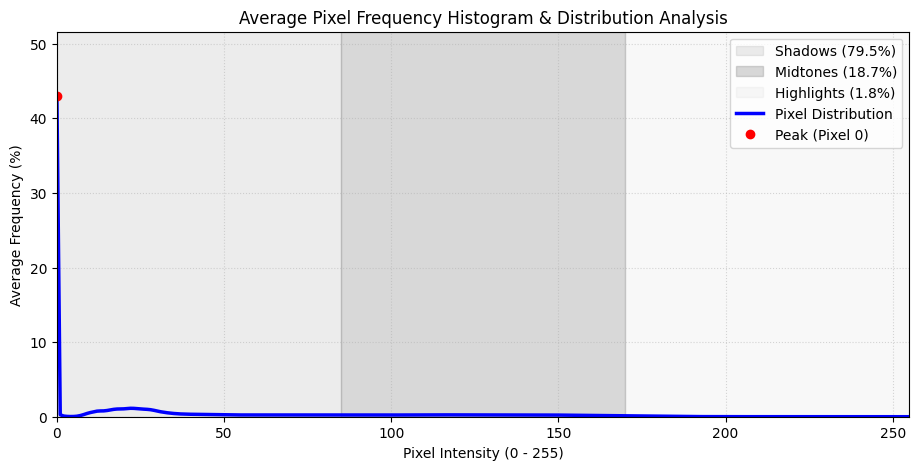

In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def analyze_pixel_distribution(folder_path):
    # Khởi tạo mảng tích lũy tần suất (256 mức xám)
    total_frequency = np.zeros((256, 1))
    valid_image_count = 0
    
    # Định dạng ảnh được hỗ trợ
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp')
    
    # Quét dữ liệu trong thư mục
    for file_name in os.listdir(folder_path):
        if file_name.lower().endswith(valid_extensions):
            file_path = os.path.join(folder_path, file_name)
            img_gray = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
            
            if img_gray is not None:
                hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256])
                total_pixels = img_gray.shape[0] * img_gray.shape[1]
                total_frequency += (hist / total_pixels)
                valid_image_count += 1
                
    if valid_image_count == 0:
        print("Không tìm thấy ảnh hợp lệ.")
        return

    # Tính tần suất phần trăm trung bình
    average_percentage = (total_frequency / valid_image_count) * 100

    # 1. PHÂN TÍCH VÙNG PHÂN PHỐI NHIỀU NHẤT
    # Tính tổng phần trăm pixel rơi vào từng vùng sắc độ
    shadows_pct = np.sum(average_percentage[0:86])
    midtones_pct = np.sum(average_percentage[86:171])
    highlights_pct = np.sum(average_percentage[171:256])
    
    # Tìm giá trị pixel đơn lẻ xuất hiện nhiều nhất (Đỉnh biểu đồ)
    most_frequent_pixel = np.argmax(average_percentage)
    highest_pixel_pct = average_percentage[most_frequent_pixel][0]

    # In kết quả phân tích ra terminal
    print("=" * 50)
    print(f"KẾT QUẢ PHÂN TÍCH PHÂN PHỐI PIXEL ({valid_image_count} ảnh):")
    print("=" * 50)
    print(f"- Vùng tối (Shadows - 0-85)      : {shadows_pct:.2f}%")
    print(f"- Vùng trung tính (Midtones - 86-170): {midtones_pct:.2f}%")
    print(f"- Vùng sáng (Highlights - 171-255)  : {highlights_pct:.2f}%")
    print("-" * 50)
    
    # Xác định vùng chiếm ưu thế lớn nhất
    regions = {"Vùng tối (Shadows)": shadows_pct, "Vùng trung tính (Midtones)": midtones_pct, "Vùng sáng (Highlights)": highlights_pct}
    dominant_region = max(regions, key=regions.get)
    print(f"👉 Vùng chiếm tỷ lệ nhiều nhất: {dominant_region} ({regions[dominant_region]:.2f}%)")
    print(f"👉 Mức xám đơn lẻ xuất hiện nhiều nhất là: {most_frequent_pixel} (Chiếm {highest_pixel_pct:.2f}% tổng số pixel)")
    print("=" * 50)

    # 2. VẼ BIỂU ĐỒ TRỰC QUAN HÓA
    plt.figure(figsize=(11, 5))
    plt.title(f"Average Pixel Frequency Histogram & Distribution Analysis")
    plt.xlabel("Pixel Intensity (0 - 255)")
    plt.ylabel("Average Frequency (%)")
    
    # Vẽ các vùng màu nền để dễ nhận diện trên biểu đồ
    plt.axvspan(0, 85, color='gray', alpha=0.15, label=f'Shadows ({shadows_pct:.1f}%)')
    plt.axvspan(85, 170, color='gray', alpha=0.3, label=f'Midtones ({midtones_pct:.1f}%)')
    plt.axvspan(170, 255, color='gray', alpha=0.05, label=f'Highlights ({highlights_pct:.1f}%)')
    
    # Vẽ đường histogram trung bình
    plt.plot(average_percentage, color='blue', linewidth=2.5, label='Pixel Distribution')
    
    # Đánh dấu đỉnh cao nhất bằng chấm đỏ
    plt.plot(most_frequent_pixel, highest_pixel_pct, 'ro', label=f'Peak (Pixel {most_frequent_pixel})')
    
    plt.xlim([0, 255])
    plt.ylim([0, np.max(average_percentage) * 1.2])
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()

# --- Chạy thử nghiệm ---
folder_path ="dataset/train"
analyze_pixel_distribution(folder_path)
